<a target="_blank" href="https://colab.research.google.com/github/fintech-dl-hse/course/blob/main/seminars/07_vae_diffusion/07_vae_diffusion.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Семинар 7: AE, VAE, Diffusion

## План

- Recap
- AE
- VAE
- Diffusion
- Блиц
- Домашки

## Recap: GAN

На прошлом занятии мы разобрали **GAN**:

- **Генератор** $G$ получает случайный шум $z$ и пытается сгенерировать реалистичный объект.
- **Дискриминатор** $D$ получает объект и предсказывает, настоящий он или сгенерированный.
- Обучение идёт в формате **adversarial training**: генератор и дискриминатор соревнуются, и за счёт этого генератор постепенно улучшает качество выборок.

GAN — мощный подход, но не единственный. Помимо GAN есть и другие генеративные модели: **AE, VAE, Diffusion**. В этом семинаре фокусируемся на них и сравниваем их идеи с GAN-подходом.

## AutoEncoder

**Автоэнкодер** — модель из двух частей: **encoder** переводит вход в компактное представление (латент), **decoder** по латенту восстанавливает вход. Задача обучения — минимизировать **reconstruction loss** (например, MSE или L1 между входом и выходом). Узкое место между encoder и decoder (bottleneck) заставляет модель выделять главные признаки.

Классические автоэнкодеры ([Hinton & Salakhutdinov, 2006](https://www.cs.toronto.edu/~hinton/science.pdf)) использовались для предобучения и сжатия; сейчас их применяют для генерации (интерполяция в латенте), детекции аномалий и как часть более сложных моделей.

In [ ]:
from torchvision.datasets import MNIST
import torchvision.transforms as transformsv1

import torch.nn as nn
from torch.optim import Adam
import torch
import torch.utils.data
from torch.utils.data import DataLoader

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

In [ ]:
transforms = transformsv1.Compose([
    transformsv1.ToTensor(),
])

mnist_dataset = MNIST("./MNIST", download=True, transform=transforms)

len(mnist_dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.0MB/s]


60000

In [ ]:
class ImageEncoder(nn.Module):
    """Свёрточный encoder: изображение [B, 1, 28, 28] -> латент [B, latent_dim*14*14]."""

    def __init__(self, latent_dim=128):
        super().__init__()

        self.latent_dim = latent_dim

        self.sequential = nn.Sequential(*[
            nn.BatchNorm2d(1),
            nn.Conv2d(1, 64, kernel_size=3, padding=1),   # [ bs, 64, 28, 28 ]
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # [ bs, 128, 28, 28 ]
            nn.MaxPool2d(2),                              # [ bs, 128, 14, 14 ]
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, self.latent_dim, kernel_size=1),     # [ bs, latent_dim, 14, 14 ]
            nn.Flatten(1),
        ])

    def forward(self, images_batch):
        return self.sequential(images_batch)


class ImageDecoder(nn.Module):
    """Свёрточный decoder: латент [B, latent_dim*14*14] -> изображение [B, 1, 28, 28]."""

    def __init__(self, latent_dim=128):
        super().__init__()

        self.latent_dim = latent_dim

        self.sequential = nn.Sequential(*[
            nn.Unflatten(1, (self.latent_dim, 14, 14)),
            nn.BatchNorm2d(self.latent_dim),
            nn.Conv2d(128, 64, kernel_size=1), # [ bs, 64, 14, 14 ]
            nn.Upsample([28, 28]),             # [ bs, 64, 28, 28 ]
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 1, kernel_size=3, padding=1), # [ bs, 1, 28, 28 ]
            nn.ReLU(),
            nn.BatchNorm2d(1),
            nn.Conv2d(1, 1, kernel_size=3, padding=1), # [ bs, 1, 28, 28 ]
            nn.Sigmoid(),
        ])

    def forward(self, image_embedding):
        # image_embedding ~ [ bs, 128 ]
        # print("image_embedding", image_embedding.shape)
        assert len(image_embedding.shape) == 2
        assert image_embedding.shape[1] == self.latent_dim * 14 * 14, f"{image_embedding.shape[1]} == {self.latent_dim}"
        # image_embedding = image_embedding.reshape(-1, self.latent_dim)
        return self.sequential(image_embedding)



In [ ]:
class AutoEncoder(nn.Module):
    """Автоэнкодер: encoder + decoder, forward возвращает восстановленное изображение."""

    def __init__(self):
        super().__init__()

        self.encoder = ImageEncoder()
        self.decoder = ImageDecoder()

    def encode(self, images_batch):
        return self.encoder(images_batch)

    def decode(self, images_embeddings):
        return self.decoder(images_embeddings)

    def forward(self, images_batch):
        images_embeddings = self.encode(images_batch)
        # if self.training:
        #     images_embeddings += torch.randn_like(images_embeddings)
        return self.decode(images_embeddings)



In [ ]:
mnist_dataset[0][0].shape

torch.Size([1, 28, 28])

In [ ]:
AutoEncoder().forward( torch.rand( [ 5, 1, 28, 28 ] ) ).shape

torch.Size([5, 1, 28, 28])

In [ ]:
def train(
    model: nn.Module,
    dataset: torch.utils.data.Dataset,
    loss_function: nn.Module,
    num_epochs: int = 10,
    device: str = "cuda",
    learning_rate: float = 3e-4,
) -> None:
    """
    Обучает модель (AE/VAE) на датасете с разделением на train/val.

    Args:
        model: Модель с forward(x) -> recon (и опционально mu, logvar для VAE).
        dataset: Датасет изображений.
        loss_function: Функция потерь (recon, x) или (recon, x, mu, logvar).
        num_epochs: Количество эпох.
        device: Устройство (cuda/cpu).
        learning_rate: Learning rate для Adam.
    """
    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1], generator=generator)
    model = model.to(device)

    optimizer = Adam(model.parameters(), lr=learning_rate)

    train_dataloader = DataLoader(train_dataset, batch_size=100, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=100, shuffle=False)


    progress_bar = tqdm(range(num_epochs), total=num_epochs, desc="Epoch")
    for epoch_num in progress_bar:

        # train dataloader
        train_losses_sum = torch.tensor([0.0], device=device)
        train_iterations = 0
        for images_batch in train_dataloader:
            images_batch = images_batch[0].to(device)

            restored_images_batch = model(images_batch)

            loss = loss_function(restored_images_batch, images_batch)

            train_losses_sum += loss.detach()
            train_iterations += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # validation
        val_losses_sum = torch.tensor([0.0], device=device)
        valid_iterations = 0
        with torch.no_grad():
            for images_batch in val_dataloader:
                images_batch = images_batch[0].to(device)

                valid_iterations += 1
                restored_images_batch = model(images_batch)
                loss = loss_function(restored_images_batch, images_batch)

                val_losses_sum += loss.mean()

        mean_val_loss = (val_losses_sum / valid_iterations).item()
        mean_train_loss = (train_losses_sum / train_iterations).item()
        progress_bar.set_postfix({"val_loss": f"{mean_val_loss:.2f}", "train_loss": f"{mean_train_loss:.2f}"})
        # print(f"epoch {epoch_num} val_loss={mean_val_loss}")




In [ ]:
autoencoder = AutoEncoder()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

generator = torch.Generator().manual_seed(42)

# cfair_dataset_5p, _ = torch.utils.data.random_split(cfair_dataset, [0.1, 0.9], generator=generator)
# print("cfair_dataset_5p", len(cfair_dataset_5p))
train(autoencoder, mnist_dataset, nn.L1Loss(), device=device, num_epochs=10, learning_rate=3e-4)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
@torch.no_grad()
def linear_latent_space_interpolation(
    model: nn.Module,
    image_from: torch.Tensor,
    image_to: torch.Tensor,
    device: str = "cpu",
    num_interpolation_steps: int = 10,
) -> list:
    """
    Строит линейную интерполяцию между двумя изображениями в латентном пространстве модели.

    Args:
        model: Модель с методами encode и decode.
        image_from: Исходное изображение (без batch).
        image_to: Конечное изображение.
        device: Устройство.
        num_interpolation_steps: Количество шагов интерполяции.

    Returns:
        Список массивов восстановленных изображений по шагам.
    """
    model.eval()
    image_from = image_from.unsqueeze(0).to(device)
    image_to = image_to.unsqueeze(0).to(device)
    model = model.to(device)

    latent_space_from = model.encode(image_from)
    latent_space_to = model.encode(image_to)

    latent_space_steps = torch.linspace(0, 1, num_interpolation_steps)

    latent_diff = latent_space_to - latent_space_from

    restored_images = []
    for latent_step_portion in latent_space_steps:
        latent_step = latent_diff * latent_step_portion
        latent_interpolation = latent_space_from + latent_step

        restored_image = model.decode(latent_interpolation).detach().clip(0, 1).cpu().numpy()[0]
        restored_images.append(restored_image)

    return restored_images

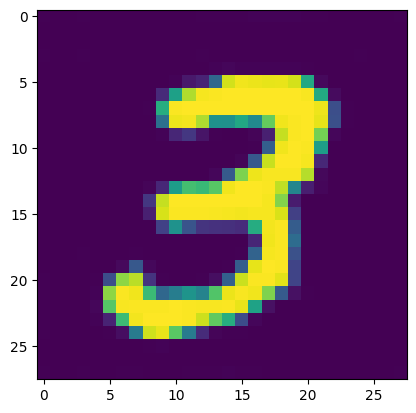

In [ ]:
autoencoder.eval()
zero_autoencoder_prediction = autoencoder(mnist_dataset[7][0].unsqueeze(0).to(device))
plt.imshow(zero_autoencoder_prediction.permute(0, 2, 3, 1).detach().cpu().numpy()[0])

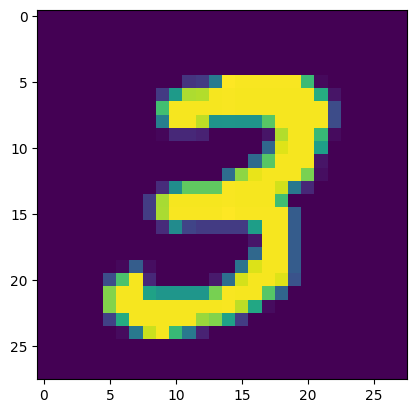

In [ ]:
plt.imshow(mnist_dataset[7][0].permute(1,2, 0).numpy())

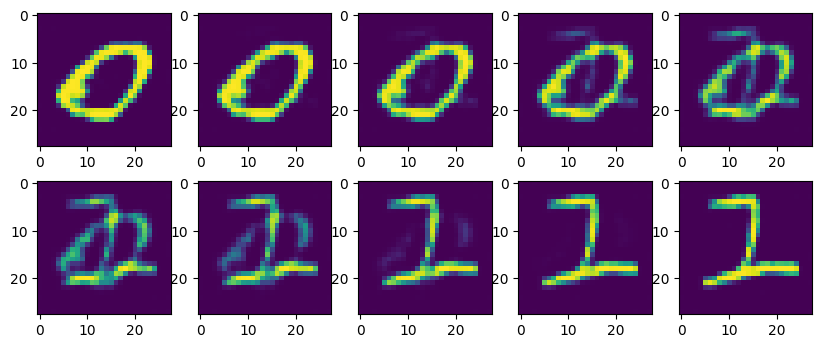

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

autoencoder_interpolated = linear_latent_space_interpolation(
    autoencoder, mnist_dataset[1][0], mnist_dataset[2][0],
    device=device,
    num_interpolation_steps=10
)

_, axs = plt.subplots(2, 5, figsize=(10, 4))
axs = axs.flatten()
for img, ax in zip(autoencoder_interpolated, axs):
    ax.imshow(img.T)
plt.show()

---

In [21]:
from html import escape
from IPython.display import HTML, display
from pathlib import Path

html_text = Path("static/ae_vs_vae_latent_space.html").read_text(encoding="utf-8")
display(HTML(html_text))

## VAE (Variational AutoEncoder)

**Мотивация:** У обычного AE латентное пространство может быть «рваным»: близкие точки в латенте не обязательно дают похожие изображения. Генерация как сэмплирование из латента ненадёжна. **VAE** [Kingma & Welling, 2013](https://arxiv.org/abs/1312.6114) моделирует латент как случайную величину с нормальным распределением $q_\phi(z|x)$ (encoder выдаёт $\mu$ и $\log\sigma^2$), а декодер восстанавливает $x$ из $z$.


**Reparametrization trick:** Сэмплирование $z \sim \mathcal{N}(\mu, \sigma^2)$ недифференцируемо по $\mu, \sigma$. Пишем $z = \mu + \sigma \cdot \epsilon$, где $\epsilon \sim \mathcal{N}(0, 1)$ — градиенты идут по $\mu$ и $\sigma$.

<img src="static/ae_vae.png" width=600 />

In [19]:
from html import escape
from IPython.display import HTML, display
from pathlib import Path

html_text = Path("static/elbo.html").read_text(encoding="utf-8")
html_text = html_text.replace("<body>", '<body style="background:#faf9f6;">', 1)
iframe = (
    '<iframe style="width:100%;height:650px;border:0;background:#faf9f6;" '
    'srcdoc="{srcdoc}"></iframe>'
).format(srcdoc=escape(html_text, quote=True))
display(HTML(iframe))

In [15]:
def reparametrize(mu: torch.Tensor, logvar: torch.Tensor, generator: torch.Generator | None = None) -> torch.Tensor:
    """
    Reparametrization trick: z = mu + sigma * epsilon, epsilon ~ N(0, 1).
    Позволяет backprop через сэмпл z по параметрам mu и logvar.

    Args:
        mu: Средние [B, latent_dim].
        logvar: Логарифм дисперсии [B, latent_dim].
        generator: Генератор для воспроизводимости.

    Returns:
        Сэмпл z [B, latent_dim], дифференцируемый по mu и logvar.
    """
    sigma = torch.exp(0.5 * logvar)
    epsilon = torch.randn_like(mu, generator=generator)
    return mu + sigma * epsilon


# Проверка: градиенты должны идти по mu и logvar
torch.manual_seed(42)
mu = torch.randn(2, 4, requires_grad=True)
logvar = torch.zeros(2, 4, requires_grad=True)
z = reparametrize(mu, logvar)
loss = z.sum()
loss.backward()
assert mu.grad is not None and logvar.grad is not None, "Градиенты по mu и logvar должны быть вычислены"
print("Reparametrization trick: градиенты по mu и logvar успешно вычислены.")
print("mu.grad norm:", mu.grad.norm().item())
print("logvar.grad norm:", logvar.grad.norm().item())

Reparametrization trick: градиенты по mu и logvar успешно вычислены.
mu.grad norm: 2.8284270763397217
logvar.grad norm: 1.342544436454773


#### ❓ **Вопрос**: Что произойдет, если убрать KL-слагаемое из лосса VAE?

<details>

<summary><strong>Ответ</strong></summary>

Модель начнет работать почти как обычный автоэнкодер: реконструкция станет лучше на train,</br>
но латентное пространство перестанет быть гладким и согласованным с $\mathcal{N}(0, I)$.</br>
Из-за этого генерация новых сэмплов из случайного $z$ обычно заметно ухудшается.</br>

</details>

#### ❓ **Вопрос**: Как меняется поведение модели, если слишком сильно увеличить вес KL (beta в beta-VAE)?

<details>

<summary><strong>Ответ</strong></summary>

Сильный KL принуждает постериор быть слишком близким к prior,</br>
поэтому латентный код несет мало информации о входе (posterior collapse).</br>
Реконструкции становятся более размытыми/плохими, но латентное пространство может быть более регулярным.</br>

</details>

#### ❓ **Вопрос**: Чем отличается “хорошая реконструкция” от “хорошего латентного пространства”?

<details>

<summary><strong>Ответ</strong></summary>

Хорошая реконструкция означает, что декодер точно восстанавливает конкретные входы.</br>
Хорошее латентное пространство означает, что в нем есть структура: близкие объекты рядом,</br>
интерполяции осмысленны, а случайная выборка из prior дает правдоподобные примеры.</br>
Идеально нужен баланс между этими двумя целями.</br>

</details>



---

## Diffusion

<image src="static/ddpm.png">


### DDPM

**DDPM (Denoising Diffusion Probabilistic Models)** — это генеративные модели, которые учатся постепенно восстанавливать данные из шума. Идея состоит из двух процессов:

- **Forward process**: на каждом шаге к данным добавляется небольшой гауссов шум, и в итоге после многих шагов получаем почти чистый шум.
- **Reverse process**: модель учится по зашумлённому объекту $x_t$ и номеру шага $t$ предсказывать шум (или эквивалентно направление денойзинга), чтобы постепенно двигаться обратно к данным.

В этой реализации модель предсказывает именно **шум $\epsilon$**, а `NoiseScheduler` задаёт коэффициенты и формулы для добавления/удаления шума.

Код основан на https://github.com/tanelp/tiny-diffusion/tree/master

In [1]:
! curl https://raw.githubusercontent.com/tanelp/tiny-diffusion/master/static/DatasaurusDozen.tsv -o static/DatasaurusDozen.tsv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 64046  100 64046    0     0  65439      0 --:--:-- --:--:-- --:--:-- 65486


In [2]:
import numpy as np
import pandas as pd
import torch

from torch.utils.data import TensorDataset

def dino_dataset(n=8000):
    df = pd.read_csv("static/DatasaurusDozen.tsv", sep="\t")
    df = df[df["dataset"] == "dino"]

    rng = np.random.default_rng(42)
    ix = rng.integers(0, len(df), n)
    x = df["x"].iloc[ix].tolist()
    x = np.array(x) + rng.normal(size=len(x)) * 0.15
    y = df["y"].iloc[ix].tolist()
    y = np.array(y) + rng.normal(size=len(x)) * 0.15
    x = (x/54 - 1) * 4
    y = (y/48 - 1) * 4
    X = np.stack((x, y), axis=1)
    return TensorDataset(torch.from_numpy(X.astype(np.float32)))

def get_dataset(name, n=8000):
    if name == "dino":
        return dino_dataset(n)
    else:
        raise ValueError(f"Unknown dataset: {name}")

### Компонент позиционных эмбеддингов

Шаг диффузии $t$ и координаты входа кодируются через **learnable positional embeddings**. Это помогает MLP учитывать **время** (уровень шума) и работать с более выразительным представлением входа.

In [3]:
'''Learnable positional embeddings для DDPM.'''

import torch
from torch import nn
from torch.nn import functional as F

class LearnablePositionalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale
        self.layer = nn.Sequential(
            nn.Linear(1, size),
            nn.GELU(),
            nn.Linear(size, size),
        )

    def forward(self, x: torch.Tensor):
        x = x.float().unsqueeze(-1) * self.scale
        return self.layer(x)

    def __len__(self):
        return self.size

class PositionalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.layer = LearnablePositionalEmbedding(size=size, scale=scale)

    def forward(self, x: torch.Tensor):
        return self.layer(x)

### Модель шума и `NoiseScheduler`

- **Модель (`MLP`)** получает пару `(x_t, t)` и предсказывает шум $\epsilon_\theta(x_t, t)$.
- **`NoiseScheduler`** хранит расписание `beta/alpha` и все предвычисленные коэффициенты для:
  - добавления шума в прямом процессе (`add_noise`),
  - шага обратного процесса при генерации (`step`),
  - вспомогательных вычислений `reconstruct_x0`, `q_posterior` и дисперсии.

Именно связка «модель + scheduler» реализует практический DDPM-пайплайн.

In [4]:
# https://github.com/tanelp/tiny-diffusion/blob/master/ddpm.py

import argparse
import os

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import numpy as np


class Block(nn.Module):
    def __init__(self, size: int):
        super().__init__()

        self.ff = nn.Linear(size, size)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor):
        return x + self.act(self.ff(x))


class MLP(nn.Module):
    def __init__(self, hidden_size: int = 128, hidden_layers: int = 3, emb_size: int = 128):
        super().__init__()

        self.time_mlp = PositionalEmbedding(emb_size)
        self.input_mlp1 = PositionalEmbedding(emb_size, scale=25.0)
        self.input_mlp2 = PositionalEmbedding(emb_size, scale=25.0)

        concat_size = len(self.time_mlp.layer) + \
            len(self.input_mlp1.layer) + len(self.input_mlp2.layer)
        layers = [nn.Linear(concat_size, hidden_size), nn.GELU()]
        for _ in range(hidden_layers):
            layers.append(Block(hidden_size))
        layers.append(nn.Linear(hidden_size, 2))
        self.joint_mlp = nn.Sequential(*layers)

    def forward(self, x, t):
        # x имеет форму [batch_size, 2]
        # В этой реализации ожидается фиксированная размерность входа
        x1_emb = self.input_mlp1(x[:, 0])
        x2_emb = self.input_mlp2(x[:, 1])
        t_emb = self.time_mlp(t)
        x = torch.cat((x1_emb, x2_emb, t_emb), dim=-1)
        x = self.joint_mlp(x)
        return x

class NoiseScheduler():
    def __init__(self,
                 num_timesteps=1000,
                 beta_start=0.0001,
                 beta_end=0.02,
                 beta_schedule="linear"):

        self.num_timesteps = num_timesteps
        if beta_schedule == "linear":
            self.betas = torch.linspace(
                beta_start, beta_end, num_timesteps, dtype=torch.float32)
        elif beta_schedule == "quadratic":
            self.betas = torch.linspace(
                beta_start ** 0.5, beta_end ** 0.5, num_timesteps, dtype=torch.float32) ** 2

        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.alphas_cumprod_prev = F.pad(
            self.alphas_cumprod[:-1], (1, 0), value=1.)

        # Предрасчёты для добавления шума в прямом процессе
        self.sqrt_alphas_cumprod = self.alphas_cumprod ** 0.5
        self.sqrt_one_minus_alphas_cumprod = (1 - self.alphas_cumprod) ** 0.5

        # Предрасчёты для восстановления оценки x0
        self.sqrt_inv_alphas_cumprod = torch.sqrt(1 / self.alphas_cumprod)
        self.sqrt_inv_alphas_cumprod_minus_one = torch.sqrt(
            1 / self.alphas_cumprod - 1)

        # Предрасчёты для параметров q-постериора
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1. - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1. - self.alphas_cumprod)

    def reconstruct_x0(self, x_t, t, noise):
        s1 = self.sqrt_inv_alphas_cumprod[t]
        s2 = self.sqrt_inv_alphas_cumprod_minus_one[t]
        s1 = s1.reshape(-1, 1)
        s2 = s2.reshape(-1, 1)
        return s1 * x_t - s2 * noise

    def q_posterior(self, x_0, x_t, t):
        s1 = self.posterior_mean_coef1[t]
        s2 = self.posterior_mean_coef2[t]
        s1 = s1.reshape(-1, 1)
        s2 = s2.reshape(-1, 1)
        mu = s1 * x_0 + s2 * x_t
        return mu

    def get_variance(self, t):
        if t == 0:
            return 0

        variance = self.betas[t] * (1. - self.alphas_cumprod_prev[t]) / (1. - self.alphas_cumprod[t])
        variance = variance.clip(1e-20)
        return variance

    # Реализует один шаг обратного процесса
    # https://arxiv.org/pdf/2208.11970
    # Сэмплирование
    def step(self, model_output, timestep, sample):
        t = timestep
        pred_original_sample = self.reconstruct_x0(sample, t, model_output)
        # TODO: проверить, нужно ли здесь использовать t-1
        pred_prev_sample = self.q_posterior(pred_original_sample, sample, t)

        variance = 0
        if t > 0:
            noise = torch.randn_like(model_output)
            variance = (self.get_variance(t) ** 0.5) * noise

        pred_prev_sample = pred_prev_sample + variance

        return pred_prev_sample

    # Обучение: добавление шума по выбранным таймстепам
    def add_noise(self, x_start, x_noise, timesteps):
        s1 = self.sqrt_alphas_cumprod[timesteps]
        s2 = self.sqrt_one_minus_alphas_cumprod[timesteps]

        s1 = s1.reshape(-1, 1)
        s2 = s2.reshape(-1, 1)

        return s1 * x_start + s2 * x_noise

    def __len__(self):
        return self.num_timesteps

In [5]:
from dataclasses import dataclass

@dataclass
class TrainingConfig():
    experiment_name ="base"
    dataset ="dino" # варианты=["circle", "dino", "line", "moons"]
    train_batch_size = 32
    eval_batch_size = 1000
    num_epochs = 200
    learning_rate = 1e-3
    num_timesteps = 1000
    beta_schedule = "linear" # варианты=["linear", "quadratic"]
    embedding_size = 128
    hidden_size = 128
    hidden_layers = 3
    save_images_step = 5

config = TrainingConfig()

dataset = get_dataset(config.dataset)
dataloader = DataLoader(
    dataset, batch_size=config.train_batch_size, shuffle=True, drop_last=True)


model = MLP(
    hidden_size=config.hidden_size,
    hidden_layers=config.hidden_layers,
    emb_size=config.embedding_size)

noise_scheduler = NoiseScheduler(
    num_timesteps=config.num_timesteps,
    beta_schedule=config.beta_schedule)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
)

#### ❓ **Вопрос**: На каких слоях и как используются timestep'ы в диффузионных моделях?

<details>

<summary><strong>Ответ</strong></summary>

Есть разные подходы: можно конкатенировать обучаемый эмбэддинг с вектором признаков и передать в MLP; можно закодировать через AdaLayerNorm — по сути добавляет смещение для сгенерированного сэмпла ([пример в diffusers](https://github.com/huggingface/diffusers/blob/fdb05f54ef61007a8f77ad8537b292176d13fafb/src/diffusers/models/normalization.py#L28)).</br>

</details>

#### ❓ **Вопрос**: Что является результатом вычисления `.forward()` для диффузионки?

<details>

<summary><strong>Ответ</strong></summary>

Обычно предсказывается шум, который надо вычесть из сэмпла.</br>
Но есть разные стратегии: можно предсказывать шум; можно предсказывать предыдущий сэмпл $x_{t-1}$; можно предсказывать исходный сэмпл $x_0$.</br>

**Сравнение параметризаций в диффузионных моделях**

Из $\mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon}$ любые два из трёх $(\mathbf{x}_t, \mathbf{x}_0, \boldsymbol{\epsilon})$ однозначно определяют третий. Поэтому все параметризации алгебраически эквивалентны — разница только в неявном взвешивании loss по $t$.

| | $\boldsymbol{\epsilon}$-prediction | $\mathbf{x}_0$-prediction | $\mathbf{v}$-prediction |
|---|---|---|---|
| **Таргет** | $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ | $\mathbf{x}_0$ (чистые данные) | $\mathbf{v}_t = \sqrt{\bar\alpha_t}\,\boldsymbol{\epsilon} - \sqrt{1-\bar\alpha_t}\,\mathbf{x}_0$ |
| **Вес на $\|\mathbf{x}_0 - \hat{\mathbf{x}}_0\|^2$** | $\text{SNR}_t$ (фокус на деталях) | $1$ (равномерный) | $1 + \text{SNR}_t$ (сбалансированный) |
| **Стабильность** | ✅ Дисперсия таргета = 1 для всех $t$ | ⚠️ Большие градиенты при $t \to T$ | ✅ Дисперсия таргета = 1 для всех $t$ |
| **Где используется** | DDPM, Imagen, Guided Diffusion | Latent Diffusion, SD 1.x, DALL·E 2 | Progressive Distillation, SD 2.1+ |

</details>


#### ❓ **Вопрос**: Почему для диффузии важно, чтобы $x_t \sim q_t(x_t | x_0)$ (ф-ия `.add_noise`) можно было вычислять эффективно?

<details>

<summary><strong>Ответ</strong></summary>

Потому что во время обучения этот метод вызывается большое количество раз.</br>
В теории можно заранее насэмплировать большой датасет с зашумлением на разных шагах, но это потребует большого количества диска.</br>

</details>


---

### TrainingConfig и инициализация

`TrainingConfig` хранит гиперпараметры эксперимента: размер батча, количество эпох, число диффузионных шагов, тип расписания `beta`, размер эмбеддингов и архитектуру MLP. Ниже мы создаём датасет/дataloader, модель, `NoiseScheduler` и оптимизатор.

### Формулы для вычисления $x_t$ в диффузии

#### Рекуррентная формула

$$ x_t = \sqrt{\alpha_t}\,x_{t-1} + \sqrt{1 - \alpha_t}\,\epsilon $$

#### Нерекуррентная формула

$$ x_t = \sqrt{\overline{\alpha}_t}\,x_0 + \sqrt{1 - \overline{\alpha}_t}\,\epsilon $$

#### Как связаны $\alpha_t$ и $\beta_t$

$$ \alpha_t = 1 - \beta_t $$

$$ \overline{\alpha}_t = \prod_{s=1}^{t} \alpha_s = \prod_{s=1}^{t}(1-\beta_s) $$

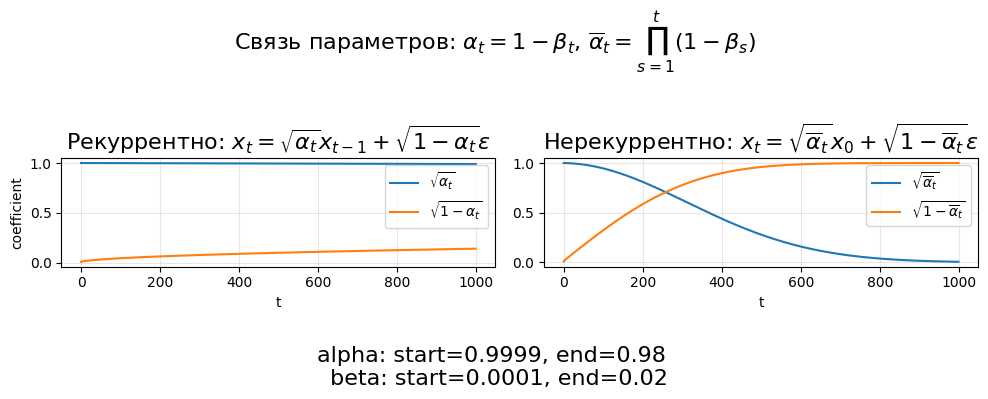

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=True)

# Начальные и конечные значения для alpha и beta
alpha_start = noise_scheduler.alphas[0].item()
alpha_end = noise_scheduler.alphas[-1].item()
beta_start = noise_scheduler.betas[0].item()
beta_end = noise_scheduler.betas[-1].item()

# Рекуррентная формула: коэффициенты при x_{t-1} и epsilon
axes[0].plot(torch.sqrt(noise_scheduler.alphas), label=r"$\sqrt{\alpha_t}$")
axes[0].plot(torch.sqrt(1 - noise_scheduler.alphas), label=r"$\sqrt{1-\alpha_t}$")
axes[0].set_title(r"Рекуррентно: $x_t=\sqrt{\alpha_t}x_{t-1}+\sqrt{1-\alpha_t}\epsilon$", fontsize=16)
axes[0].set_xlabel("t")
axes[0].set_ylabel("coefficient")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Нерекуррентная формула: коэффициенты при x_0 и epsilon
axes[1].plot(noise_scheduler.sqrt_alphas_cumprod, label=r"$\sqrt{\overline{\alpha}_t}$")
axes[1].plot(noise_scheduler.sqrt_one_minus_alphas_cumprod, label=r"$\sqrt{1-\overline{\alpha}_t}$")
axes[1].set_title(r"Нерекуррентно: $x_t=\sqrt{\overline{\alpha}_t}x_0+\sqrt{1-\overline{\alpha}_t}\epsilon$", fontsize=16)
axes[1].set_xlabel("t")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle(r"Связь параметров: $\alpha_t=1-\beta_t$, $\overline{\alpha}_t=\prod_{s=1}^{t}(1-\beta_s)$", y=1.05, fontsize=16)
fig.text(
    0.5,
    -0.2,
    f"alpha: start={alpha_start:.4f}, end={alpha_end:.2f} \n beta: start={beta_start:.4f}, end={beta_end:.2f}",
    ha="center",
    fontsize=16,
)
fig.tight_layout()
plt.show()


#### ❓ **Вопрос**: Что интуитивно означает расписание beta_t и почему его форма важна?

<details>

<summary><strong>Ответ</strong></summary>

$\beta_t$ задает, сколько нового шума добавляется на шаге $t$.</br>
Форма расписания определяет, как быстро теряется информация о данных по времени:</br>
слишком резкое зашумление делает задачу денойзинга тяжелой, слишком мягкое - неэффективной по числу шагов.</br>
Поэтому от расписания напрямую зависят стабильность обучения и качество/скорость сэмплирования.</br>

</details>



In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Берем все точки динозавра и фиксируем шум для воспроизводимости.
x0 = dataset.tensors[0].cpu()
noise_generator = torch.Generator().manual_seed(42)
fixed_noise = torch.randn(x0.shape, generator=noise_generator)

def plot_forward_diffusion(t: int) -> None:
    timesteps = torch.full((x0.shape[0],), t, dtype=torch.long)
    x_t = noise_scheduler.add_noise(x0, fixed_noise, timesteps)
    alpha_bar_t = noise_scheduler.alphas_cumprod[t].item()

    plt.figure(figsize=(4, 4))
    plt.scatter(x0[:, 0], x0[:, 1], s=6, alpha=0.5, c="gray", label="$x_0$")
    plt.scatter(x_t[:, 0], x_t[:, 1], s=7, alpha=0.25, c="tab:blue", label="$x_t$")
    plt.title(f"Forward diffusion on dino dataset (t={t}, alpha_bar={alpha_bar_t:.4f})")
    plt.xlim(-4.5, 4.5)
    plt.ylim(-4.5, 4.5)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(alpha=0.2)
    plt.legend(loc="upper right")
    plt.show()

t_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(noise_scheduler) - 1,
    step=1,
    description="timestep",
    continuous_update=False,
)

display(widgets.interactive_output(plot_forward_diffusion, {"t": t_slider}), t_slider)

Output()

IntSlider(value=0, continuous_update=False, description='timestep', max=999)

#### ❓ **Вопрос**: Почему размытие не остается около исходных точек, а сходится к гауссиане?

<details>

<summary><strong>Ответ</strong></summary>

Из-за коэффициента $\sqrt{\bar\alpha_t}$ перед сигналом.

</details>


### Обучение и сэмплирование

В training loop на каждом шаге мы:

1. Берём батч точек $x_0$.
2. Выбираем случайный шаг $t$.
3. Строим зашумлённый объект $x_t$ через `noise_scheduler.add_noise(...)`.
4. Просим модель предсказать добавленный шум.
5. Обучаемся по MSE между истинным шумом и предсказанным.

После каждой `save_images_step` эпохи запускаем **sampling**: стартуем с гауссова шума и идём по шагам времени в обратном порядке через `noise_scheduler.step(...)`, постепенно получая точки, похожие на данные.

In [34]:


global_step = 0
frames = []
losses = []
print("Обучаем модель...")
for epoch in range(config.num_epochs):
    model.train()
    progress_bar = tqdm(total=len(dataloader))
    progress_bar.set_description(f"Эпоха {epoch}")
    for step, batch in enumerate(dataloader):
        batch = batch[0] # [batch_size, 2]
        noise = torch.rand_like(batch) # [batch_size, 2]
        timesteps = torch.randint(
            0, noise_scheduler.num_timesteps, (batch.shape[0],)
        ).long()

        noisy = noise_scheduler.add_noise(batch, noise, timesteps)
        noise_pred = model(noisy, timesteps)
        loss = F.mse_loss(noise_pred, noise)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.update(1)
        logs = {"loss": loss.detach().item(), "step": global_step}
        losses.append(loss.detach().item())
        progress_bar.set_postfix(**logs)
        global_step += 1
    progress_bar.close()

    if epoch % config.save_images_step == 0 or epoch == config.num_epochs - 1:
        # Генерируем точки, чтобы потом визуализировать прогресс обучения
        model.eval()
        sample = torch.randn(config.eval_batch_size, 2)
        timesteps = list(range(len(noise_scheduler)))[::-1]
        for i, t in enumerate(tqdm(timesteps)):
            t = torch.from_numpy(np.repeat(t, config.eval_batch_size)).long()
            with torch.no_grad():
                residual = model(sample, t)
            sample = noise_scheduler.step(residual, t[0], sample)
        frames.append(sample.numpy())

print("Сохраняем модель...")
outdir = f"exps/{config.experiment_name}"
os.makedirs(outdir, exist_ok=True)
torch.save(model.state_dict(), f"{outdir}/model.pth")

print("Сохраняем изображения...")
imgdir = f"{outdir}/images"
os.makedirs(imgdir, exist_ok=True)
frames = np.stack(frames)
xmin, xmax = -6, 6
ymin, ymax = -6, 6
for i, frame in enumerate(frames):
    plt.figure(figsize=(10, 10))
    plt.scatter(frame[:, 0], frame[:, 1])
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.savefig(f"{imgdir}/{i:04}.png")
    plt.close()

print("Сохраняем loss в numpy-массив...")
np.save(f"{outdir}/loss.npy", np.array(losses))

print("Сохраняем фреймы...")
np.save(f"{outdir}/frames.npy", frames)

Обучаем модель...


100%|██████████| 1000/1000 [00:01<00:00, 533.28it/s]


Сохраняем модель...
Сохраняем изображения...
Сохраняем loss в numpy-массив...
Сохраняем фреймы...


<img src="static/img_0.png" width=800 />


## Classifier Free Guidance (будет в домашке)

✨ **Classifier-Free Guidance (CFG)** — трюк, который делает генерацию ближе к условию (например, к текстовому промпту) без отдельного классификатора.

🧠 На сэмплинге смешиваем два предсказания шума: безусловное и условное,
$$\hat{\epsilon}=\hat{\epsilon}_{\text{uncond}} + w\big(\hat{\epsilon}_{\text{cond}}-\hat{\epsilon}_{\text{uncond}}\big).$$
🎛️ Больше $w$ -> лучше следование промпту, но меньше разнообразия и выше риск артефактов.

<img src="static/cfg.png" width=600 />

#### ❓ **Вопрос**: Как в диффузию добавить обусловленность на метку класса?

<details>

<summary><strong>Ответ</strong></summary>

Можно так же как мы кодируем таймстемп: обучить эмбэддинги и сконкатенировать с остальными входными данными.

</details>


## Еще материалы про диффузионные модели

 - [The Annotated Diffusion Model](https://huggingface.co/blog/annotated-diffusion)
 - [Diffusion Models From Scratch](https://github.com/tonyduan/diffusion/tree/main)
 - [Diffusers](https://github.com/huggingface/diffusers/)
 - [Классная лекция](https://www.youtube.com/watch?v=YeS3Td5O1kU) от AIRI по введению в диффузионки




## Блиц

### VAE

#### ❓ **Вопрос**: Чем `AutoEncoder` отличается от `VariationalAutoEncoder`? Какая мотивация?

<details>

<summary><strong>Ответ</strong></summary>

VAE задаёт латент как распределение (обычно гауссово) и обучается с ELBO: reconstruction + KL-регуляризация к $p(z)$. Из-за этого латентное пространство становится более гладким и непрерывным — интерполяция и сэмплирование дают осмысленные объекты. У обычного AE латент не регуляризован, «дыры» между кодами могут давать артефакты. Генерация в VAE: сэмплируем $z \sim \mathcal{N}(0, I)$ и прогоняем через декодер.</br>

</details>


#### ❓ **Вопрос**: Как можно использовать `AutoEncoder` для задачи поиска аномалий? Какой из вариантов автоэнкодера для этого лучше всего подходит?

<details>

<summary><strong>Ответ</strong></summary>

Смотрим на ошибку декодера. Если декодер плохо восстанавливает данные, значит этого сэмпла не было в исходной выборке, на которой мы обучились, и это скорее всего выброс.</br>

</details>


#### ❓ **Вопрос**: Автоэнкодеры — это генеративная модель? Можно ли запустить генерацию чего-либо через автоэнкодеры? Как ей управлять?

<details>

<summary><strong>Ответ</strong></summary>

Да, можно. Управлять генерацией можно через интерполяцию в латентном пространстве или сэмплирование из латента (в VAE — сэмплируем $z \sim \mathcal{N}(0, I)$ и подаём в декодер).</br>

</details>


#### ❓ **Вопрос**: Какие метрики качества можно использовать во время обучения автоэнкодеров?

<details>

<summary><strong>Ответ</strong></summary>

FID, IS (Inception Score). Обе метрики используют фичи/предсказания предобученной сети (Inception) и не требуют ручной разметки.</br>

</details>


#### ❓ **Вопрос**: Что такое reparametrization trick? Какую проблему он решает?

<details>

<summary><strong>Ответ</strong></summary>

Решает проблему распространения градиентов.</br>
Если мы просто сэмплируем из распределения с заданными параметрами — не понятно, как распространять градиенты.</br>

<img src="static/img_3.png" width=400 /></br>

</details>


---

### Diffusion

#### ❓ **Вопрос**: Зачем в диффузии нужно большое количество шагов?

<details>

<summary><strong>Ответ</strong></summary>

С меньшим кол-вом шагов работает хуже или не работает. Рекомендуется ~ 1к шагов для обучения. Но вообще говоря, после обучения можно дистиллировать модель в меньшее кол-во шагов (см. Progressive Distillation, например).</br>

</details>


#### ❓ **Вопрос**: Что такое прямой процесс диффузии? Чем отличается от обратного?

<details>

<summary><strong>Ответ</strong></summary>

Во время прямого процесса диффузии мы зашумляем картинку. Используется только во время обучения и не последовательно по шагам, и для любого $x_0$ мы можем вычислить $x_t$ в идеале за константу.</br>
Во время обратного процесса диффузии мы восстанавливаем сэмпл из шума, используя обученную модель.</br>

</details>


#### ❓ **Вопрос**: Зачем в DDPM нужен `NoiseScheduler`?

<details>

<summary><strong>Ответ</strong></summary>

`NoiseScheduler` задаёт расписание шума по шагам времени (`beta`, `alpha`) и хранит предвычисленные коэффициенты.</br>
На обучении он нужен, чтобы эффективно получать $x_t$ из $x_0$ (`add_noise`), а на генерации — чтобы делать шаг обратного процесса (`step`) и постепенно убирать шум.</br>
Без scheduler'а нам пришлось бы вручную и каждый раз пересчитывать формулы прямого и обратного процесса.</br>

</details>


#### ❓ **Вопрос**: Где обычно быстрее инференс — у VAE или у diffusion, и почему?

<details>

<summary><strong>Ответ</strong></summary>

Обычно быстрее VAE: генерация требует один проход через декодер.</br>
У diffusion классический сэмплинг итеративный и делает много шагов денойзинга, поэтому вычислительно он заметно дороже по времени.</br>

</details>



#### ❓ **Вопрос**: Какие недостатки есть у диффузионных моделей? Как с ними можно бороться?

<details>

<summary><strong>Ответ</strong></summary>

Долгий сэмплинг → бороться через дистилляцию, квантизацию или прунинг.</br>

</details>



#### ❓ **Вопрос**: Чем `reverse diffusion process` отличается от `backward`?

<details>

<summary><strong>Ответ</strong></summary>

`reverse diffusion process` - процесс денойзинга

`backward` - процесс вычисления градиентов

</details>



#### ❓ **Вопрос (бонус)**: Как можно было бы сделать диффузию в дискретном пространстве?

<details>

<summary><strong>Ответ</strong></summary>

Бонусная идея: перейти в дискретное скрытое пространство (например, в духе VQ-подходов) и задавать прямой процесс через матрицу переходов.</br>
Это уже расширенная тема за рамками основного материала семинара.</br>
Если интересно углубиться: [VQ-Diffusion](https://github.com/microsoft/VQ-Diffusion/tree/main).</br>

</details>

---

# Домашки

- VAE
- Diffusion (Classifier Free Guidance)
